In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Load the dataset
df = pd.read_parquet("../data/Single/tox21_NR-AR_featurized.parquet")  # Replace with your actual file

# Check class distribution
class_counts = df['Y'].value_counts()
class_percentage = df['Y'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(class_counts)
print("\nClass Percentage:")
print(class_percentage)


Class Distribution:
Y
0.0    6956
1.0     309
Name: count, dtype: int64

Class Percentage:
Y
0.0    95.746731
1.0     4.253269
Name: proportion, dtype: float64


In [2]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"


In [3]:
print(df["embedding"].dtype)
print(df["embedding"].head())

object
0    [0.05185101, 0.19479074, 0.052489955, -0.09554...
1    [0.12783396, -0.0024298094, -0.071678214, -0.0...
2    [0.14798662, -0.098763496, -0.14953455, -0.125...
3    [-0.0025056677, -0.045134634, -0.031868976, 0....
4    [-0.031643886, -0.07929968, 0.00910799, -0.133...
Name: embedding, dtype: object


In [ ]:
# Expanded the embedding column into separate columns
embeddings_df = pd.DataFrame(df["embedding"].tolist())

# Rename the columns
embeddings_df.columns = [f"emb_{i}" for i in range(embeddings_df.shape[1])]

# Merge back with the original dataframe (excluding the old "embedding" column)
df = df.drop(columns=["embedding"]).join(embeddings_df)

# Check the first few rows
print(df.head())


    Drug_ID                                  Drug    Y     emb_0     emb_1  \
0   TOX3021          CCOc1ccc2nc(S(N)(=O)=O)sc2c1  0.0  0.051851  0.194791   
1   TOX3020             CCN1C(=O)NC(c2ccccc2)C1=O  0.0  0.127834 -0.002430   
2   TOX3027       CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C  0.0  0.147987 -0.098763   
3  TOX20800             CC(O)(P(=O)(O)O)P(=O)(O)O  0.0 -0.002506 -0.045135   
4   TOX5110  CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C  0.0 -0.031644 -0.079300   

      emb_2     emb_3     emb_4     emb_5     emb_6  ...  emb_1014  emb_1015  \
0  0.052490 -0.095540  0.067737  0.030674  0.040858  ... -0.048855 -0.228889   
1 -0.071678 -0.088066  0.171518  0.188869  0.014349  ...  0.075897 -0.066863   
2 -0.149535 -0.125710 -0.091313 -0.064652 -0.046786  ... -0.105745 -0.045813   
3 -0.031869  0.038328  0.064750  0.058823  0.063226  ...  0.042210  0.164318   
4  0.009108 -0.133033 -0.187965 -0.015916 -0.220834  ... -0.043590 -0.168860   

   emb_1016  emb_1017  emb_1018  emb_1019  emb_102

In [ ]:

# Split data into train (80%), validation (10%), and test (10%)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['Y'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['Y'], random_state=42)

# Save the split datasets
train_df.to_parquet("../data/Single/tox21_NR-AR_train.parquet")
val_df.to_parquet("../data/Single/tox21_NR-AR_val.parquet")
test_df.to_parquet("../data/Single/tox21_NR-AR_test.parquet")

print("Datasets saved successfully.")

Datasets saved successfully.


In [ ]:
print(df.shape[1])  # First element of shape (rows, columns)

1027


In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

# Load the dataset from file
file_path = "../data/Single/tox21_NR-AR_train.parquet"  # Update this path if needed
df = pd.read_parquet(file_path)

# Separate features and target variable
X = df.filter(like="emb_")  # Selecting all embedding columns
y = df["Y"]  # Target column

# Check original class distribution
print("Original class distribution:", Counter(y))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert back to DataFrame for easy handling
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled["Y"] = y_resampled  # Add balanced target column

# Check new class distribution
print("New class distribution:", Counter(y_resampled))

# Save the resampled dataset back to a file
output_file_path = "../data/Single/tox21_NR-AR_train_resampled.parquet"
df_resampled.to_parquet(output_file_path)

print(f"Resampled dataset saved to {output_file_path}")


Original class distribution: Counter({0.0: 5565, 1.0: 247})


/tmp/ipykernel_3075/2703867027.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_resampled["Y"] = y_resampled  # Add balanced target column


New class distribution: Counter({0.0: 5565, 1.0: 5565})
Resampled dataset saved to ../data/Single/tox21_NR-AR_train_resampled.parquet


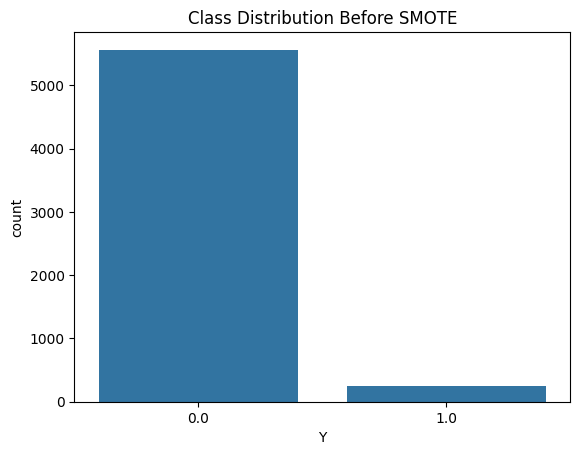

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=train_df["Y"])
plt.title("Class Distribution Before SMOTE")
plt.show()


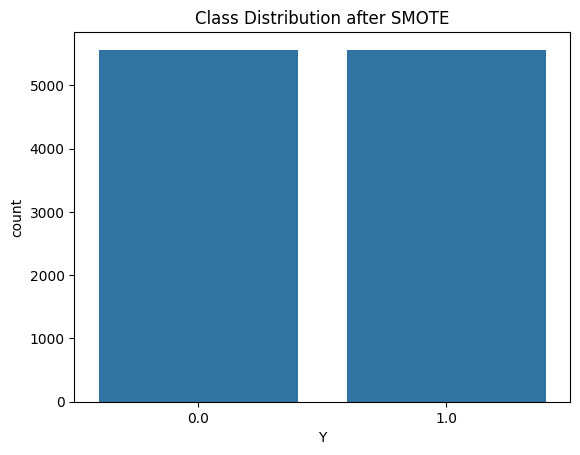

In [ ]:
sns.countplot(x=df_resampled["Y"])
plt.title("Class Distribution after SMOTE")
plt.show()

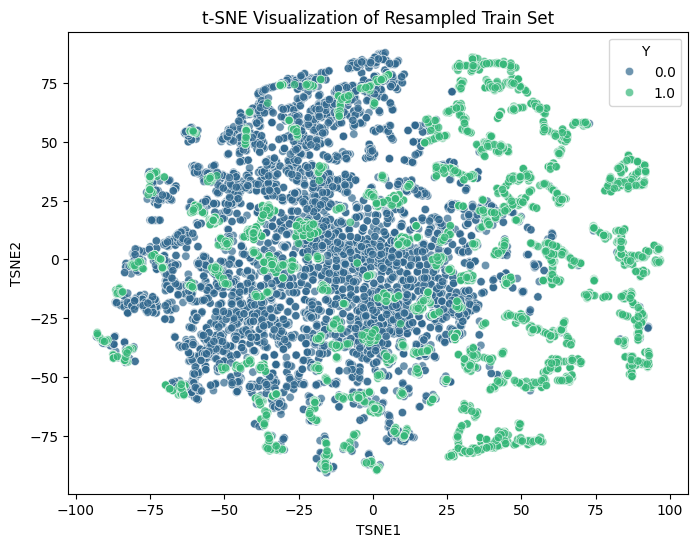

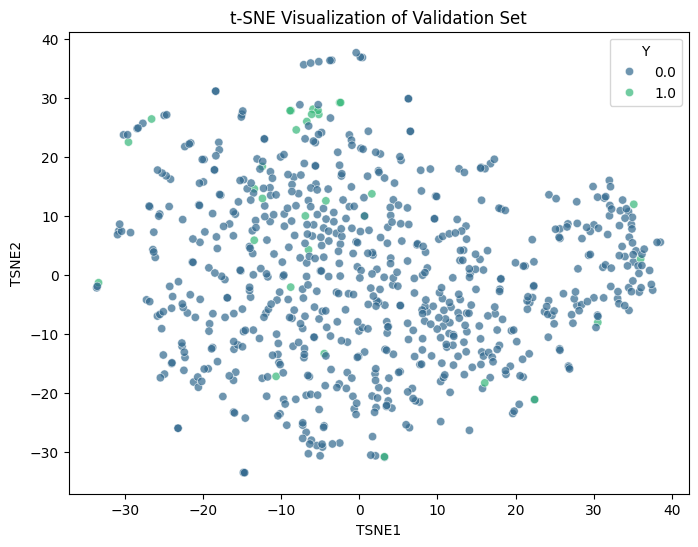

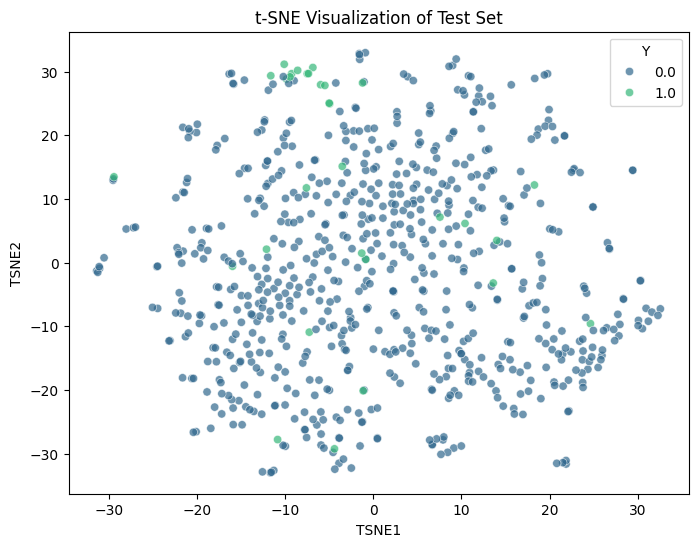

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Function to plot TSNE from file
def plot_tsne_from_file(file_path, title):
    # Load dataset
    data = pd.read_parquet(file_path)
    
    # Separate features and target
    X = data.drop(columns=["Y"])  # Drop target column
    y = data["Y"]
    
    # Convert non-numeric columns to numeric or drop them
    X = X.select_dtypes(include=[float, int])  # Keep only numerical columns
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X)
    
    # Create DataFrame for visualization
    df_embedded = pd.DataFrame(X_embedded, columns=["TSNE1", "TSNE2"])
    df_embedded["Y"] = y.values
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x="TSNE1", y="TSNE2", hue="Y", palette="viridis", data=df_embedded, alpha=0.7)
    plt.title(title)
    plt.show()

# File paths
train_file = "../data/Single/tox21_NR-AR_train_resampled.parquet"  # Resampled train set
val_file = "../data/Single/tox21_NR-AR_val.parquet"  # Original validation set
test_file = "../data/Single/tox21_NR-AR_test.parquet"  # Original test set

# Plot t-SNE for train, validation, and test sets
plot_tsne_from_file(train_file, "t-SNE Visualization of Resampled Train Set")
plot_tsne_from_file(val_file, "t-SNE Visualization of Validation Set")
plot_tsne_from_file(test_file, "t-SNE Visualization of Test Set")


In [25]:
def log_results_excel(excel_pth, model_name, dataset, hidden_layers, hidden_layer_sizes, activation_fn, train_confusion_matrix, val_confusion_matrix, test_confusion_matrix, train_loss, val_loss,test_loss, epochs, batch_size, lr, train_classification_report,val_classification_report, test_classification_report, optimizer, train_accuracy, val_accuracy, test_accuracy):
    # Read existing results
    results_df = pd.read_excel(excel_pth)
    num=len(results_df)+1
    # Create a new row as a DataFrame
    new_row = pd.DataFrame([{
        "Number":num,
        "Model": model_name,
        "Dataset": dataset,
        "Hidden Layers": hidden_layers,
        "Hidden Layer Sizes": hidden_layer_sizes,
        "Activation Function": activation_fn,
        "Train Confusion Matrix": train_confusion_matrix,
        "Validation Confusion Matrix": val_confusion_matrix,
        "Test Confusion Matrix": test_confusion_matrix,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Test Loss": test_loss,
        "Epochs": epochs,
        "Batch Size": batch_size,
        "Learning Rate": lr,
        "Train Classification Report": train_classification_report,
        "Validation Classification Report": val_classification_report,
        "Test Classification Report": test_classification_report,
        "Optimizer": optimizer,
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Test Accuracy": test_accuracy,
    }])

    # Use pd.concat instead of append
    results_df = pd.concat([results_df, new_row], ignore_index=True)

    # Save back to Excel
    results_df.to_excel(excel_pth, index=False)




In [26]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# File paths
train_file = "../data/Single/tox21_NR-AR_train_resampled.parquet"
val_file = "../data/Single/tox21_NR-AR_val.parquet"
test_file = "../data/Single/tox21_NR-AR_test.parquet"

# Load datasets
train_df = pd.read_parquet(train_file)
val_df = pd.read_parquet(val_file)
test_df = pd.read_parquet(test_file)



In [27]:
# Separate features and target
X_train, y_train = train_df.drop(columns=["Y"]), train_df["Y"]
X_val, y_val = val_df.drop(columns=["Y"]), val_df["Y"]
X_test, y_test = test_df.drop(columns=["Y"]), test_df["Y"]

In [28]:
# Ensure only numerical columns are used
X_train = X_train.select_dtypes(include=[float, int])
X_val = X_val.select_dtypes(include=[float, int])
X_test = X_test.select_dtypes(include=[float, int])

In [29]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [30]:
# Define the model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
    
])



In [31]:
from keras.optimizers import Adam

lr=0.00001
loss="binary_crossentropy"
dataset="TOX21-NR_AR"

# Define optimizer with custom learning rate
optimizer = Adam(learning_rate=lr)

# Compile the model with custom optimizer
model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)
# # =============================================
# # t-SNE Visualization of Model Embeddings
# # =============================================

# # Get embeddings from the layer before the final output (Dense-128)
# embedding_model = keras.Model(
#     inputs=model.input,
#     outputs=model.layers[-2].output  # Output of last hidden layer (128-dim)
# )

# # Generate embeddings for validation set
# val_embeddings = embedding_model.predict(X_val)

# # Apply t-SNE to reduce to 2D
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# val_embeddings_2d = tsne.fit_transform(val_embeddings)

# # Plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(
#     x=val_embeddings_2d[:, 0],
#     y=val_embeddings_2d[:, 1],
#     hue=y_val,
#     palette={0: "blue", 1: "red"},
#     alpha=0.6
# )
# plt.title("t-SNE of Model Embeddings (Validation Set)")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(title="Class", labels=["Negative", "Positive"])
# plt.show()




In [32]:
# Train the model
epoch = 150
batch_size=1024
activation = "ReLU + Sigmoid"

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epoch,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.4816 - loss: 0.9967 - val_accuracy: 0.1171 - val_loss: 1.0365
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5176 - loss: 0.9322 - val_accuracy: 0.2534 - val_loss: 0.9052
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5512 - loss: 0.8864 - val_accuracy: 0.4242 - val_loss: 0.7933
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5809 - loss: 0.8357 - val_accuracy: 0.5565 - val_loss: 0.6994
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5913 - loss: 0.8029 - val_accuracy: 0.6529 - val_loss: 0.6224
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.6237 - loss: 0.7651 - val_accuracy: 0.7727 - val_loss: 0.5593
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6369 - loss: 0.7527 - val_accuracy: 0.8140 - val_loss: 0.5077
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6522 - loss: 0.6995 - val_accuracy: 0.

In [35]:
# Save the model

PATH_TO_RESULTS="../output/Single/NR-AR/results.xlsx"
dfr = pd.read_excel(PATH_TO_RESULTS, engine='openpyxl')
model.save(f"../models/{len(dfr)+1}_tox21_classifier.h5")

In [36]:
# Evaluate on train, val, and test sets
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Train Loss: 0.0867, Train Accuracy: 0.9741
Val Loss: 0.2122, Val Accuracy: 0.9380
Test Loss: 0.2885, Test Accuracy: 0.8941


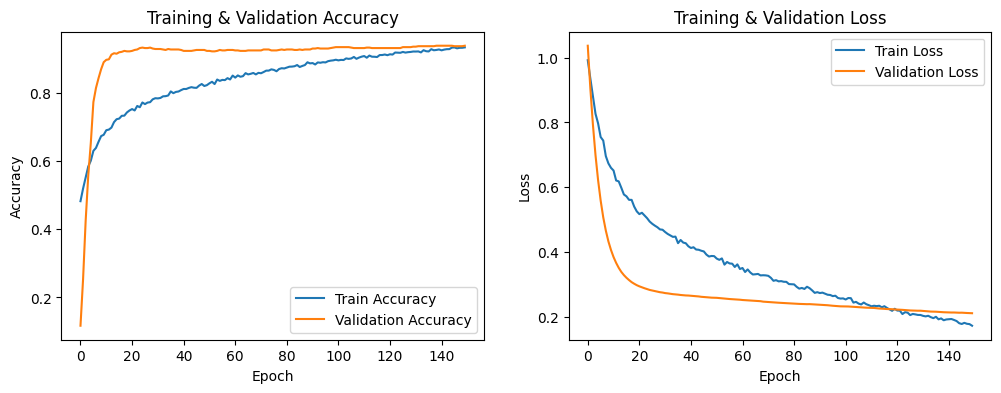

In [ ]:
# Plot training history


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Training & Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Save the plots
plt.savefig(f'../output/Single/NR-AR/{len(dfr)+1}/{len(dfr)+1}_training_history.png')

plt.show()

In [38]:
# Compute predictions for all datasets
def compute_metrics(X, y, dataset_name):
    y_pred_prob = model.predict(X)
    y_pred = (y_pred_prob > 0.5).astype("int32")
    cm = confusion_matrix(y, y_pred)
    cr=classification_report(y, y_pred)
    print(f"\n{dataset_name} Confusion Matrix:")
    print(cm)
    print(f"Classification Report:\n{classification_report(y, y_pred)}")
    return y_pred_prob, cm, cr

train_pred_prob, cm_train, cr_train = compute_metrics(X_train, y_train, "Train")
val_pred_prob, cm_val, cr_val = compute_metrics(X_val, y_val, "Validation")
test_pred_prob, cm_test, cr_test = compute_metrics(X_test, y_test, "Test")


348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Train Confusion Matrix:
[[5360  205]
 [  83 5482]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      5565
         1.0       0.96      0.99      0.97      5565

    accuracy                           0.97     11130
   macro avg       0.97      0.97      0.97     11130
weighted avg       0.97      0.97      0.97     11130

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Validation Confusion Matrix:
[[669  26]
 [ 19  12]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97       695
         1.0       0.32      0.39      0.35        31

    accuracy                           0.94       726
   macro avg       0.64      0.67      0.66       726
weighted avg       0.94      0.94      0.94       726

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Test Confusion Matrix:
[[632  64]
 [ 13  18]]
Classification Report:
      

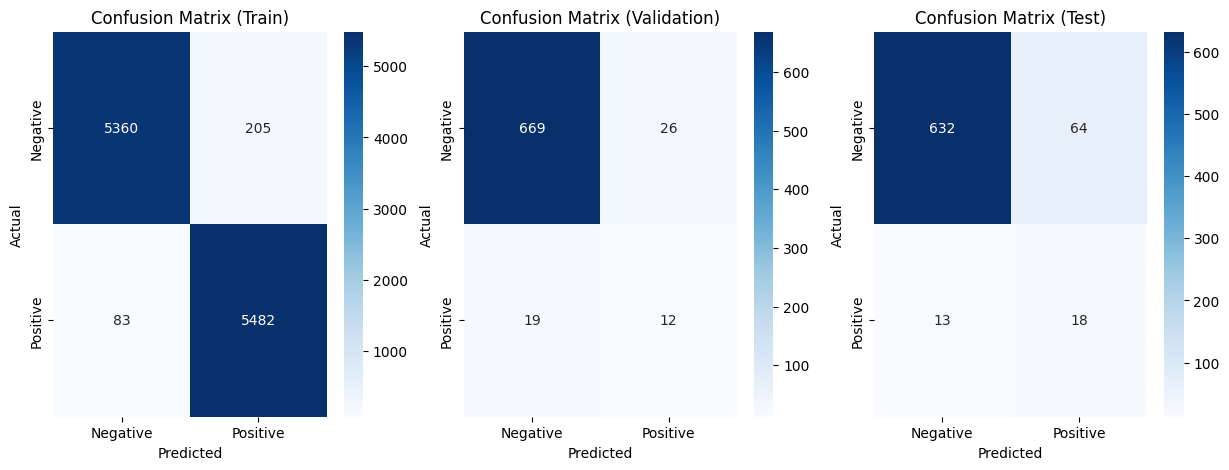

In [ ]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
datasets = [(cm_train, "Train"), (cm_val, "Validation"), (cm_test, "Test")]

for ax, (cm, title) in zip(axes, datasets):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"], ax=ax)
    ax.set_title(f"Confusion Matrix ({title})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Save the confusion matrix plot
plt.savefig(f"../output/Single/NR-AR/{len(dfr)+1}/{len(dfr)+1}_confusion_matrices.png")

plt.show()

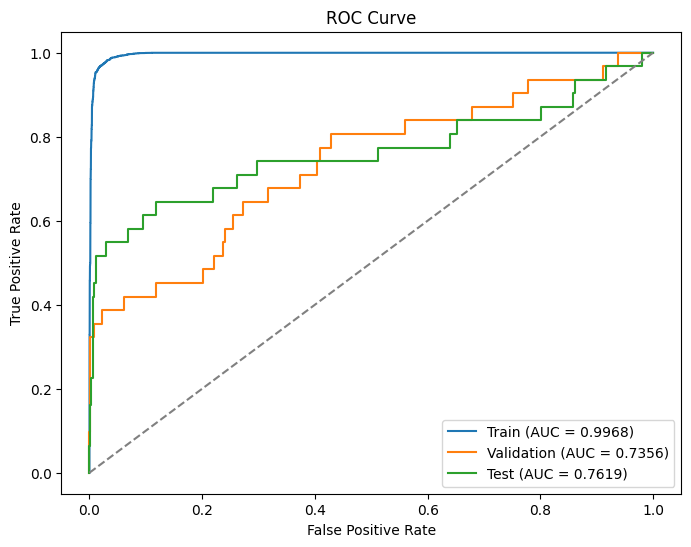

In [ ]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
for y_true, y_prob, label in zip([y_train, y_val, y_test], [train_pred_prob, val_pred_prob, test_pred_prob], ["Train", "Validation", "Test"]):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc(fpr, tpr):.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Save the ROC curve plot
plt.savefig(f"../output/Single/NR-AR/{len(dfr)+1}/{len(dfr)+1}_roc_curve.png")

plt.show()

In [41]:
log_results_excel(excel_pth=PATH_TO_RESULTS, model_name=model, dataset=dataset, hidden_layers=4, hidden_layer_sizes=[512, 256, 128, 64], activation_fn= activation, train_confusion_matrix=cm_train, val_confusion_matrix=cm_val, test_confusion_matrix=cm_test, train_loss=train_loss, val_loss=val_loss, test_loss=test_loss, epochs=epochs, batch_size=batch_size, lr=lr, train_classification_report=cr_train, val_classification_report=cr_val, test_classification_report=cr_test, optimizer=optimizer, train_accuracy=train_acc, val_accuracy=val_acc, test_accuracy=test_acc)